

```
# Tech Challenge - Fase 1
```

## 1. Definição do Problema e Planejamento

O diagnóstico de câncer de mama a partir de biópsias envolve a análise visual de características dos núcleos celulares como tamanho, forma, irregularidade do contorno. Esse processo é trabalhoso, sujeito a variações entre diferentes profissionais e exige especialização. A pergunta que motivou este trabalho foi: é possível ensinar um programa de computador a identificar padrões que separam tumores benignos de malignos com a mesma confiabilidade de um especialista?
Para responder a isso, utilizamos um conjunto de dados com 569 biópsias reais, cada uma descrita por 30 características celulares medidas em laboratório. Desses casos, 357 eram benignos e 212 malignos. Dois modelos foram treinados e comparados, o Random Forest e o KNN.


## 2. Coleta e Entendimento dos Dados

### Informações do dataset

Para treinamento e validação do modelo utilizamos o dataset disponibilizado pela <a href="https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29">Universidade da Califórnia Irvine (UCI)</a>.

Além do campo ID (identificador da amostra) e nosso target diagnosis (diagnóstico), o dataset possui os campos abaixo:

| Característica do núcleo celular | Significado |
|---------------------------------|-------------|
| radius | Média da distância do centro ao perímetro do núcleo |
| texture | Variação nos níveis de cinza da imagem |
| perimeter | Comprimento do contorno do núcleo |
| area | Área total do núcleo |
| smoothness | Variação local no comprimento do raio |
| compactness | Relação perímetro² / área − 1 |
| concavity | Severidade das porções côncavas do contorno |
| concave points | Número de pontos côncavos no contorno |
| symmetry | Simetria do núcleo |
| fractal dimension | ("aproximação do contorno" - 1) |

Cada característica do núcleo celular aparece em três versões:
* **_mean:** é a média dos valores
* **_se:** erro padrão da média (standard error). Demonstra o quão confiável é a média.
* **_worst:** maior valor observado


## 3. Análise dos Dados

In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, f1_score, accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier


In [33]:
# Lendo o arquivo do dataset e criando o dataframe
df = pd.read_csv("data.csv" , sep=",")

In [34]:
# Verificando a dimensão do dataframe
print(df.shape[0], "linhas")
print(df.shape[1], "colunas")

569 linhas
33 colunas


In [35]:
# Exibindo detalhes estruturais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5


Analisando as colunas constatamos que:

* A única coluna descritiva é o nosso target diagnosis
* Quase todos os campos possuem 569 ocorrências de dados non-null, o que já nos indica que não há colunas nulas, exceto a coluna Unnamed.

O campo Unnamed possui todas as linhas nulas o que indica ser uma má formação no nosso dataset. Sendo assim podemos excluí-lo.
  

In [36]:
# Verificando se tem algum campo nulo
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Confirmamos que 'Unnamed' é o único campo que possui valores nulos e que a quantidade de registros nulos deste campo é igual a quantidade de registros do dataset, ou seja a coluna não possui nenhum valor. A seguir faremos a exclusão para não ter que remové-lo a cada iteração.

In [37]:
# excluindo a coluna de nome 'Unnamed: 32'.
# axis=1 para indicar que está removendo a coluna.
# inplace=True indica que o dataframe original será alterado. O default (inplace=False) devolve uma cópia do dataframe com a alteração, preservando o original.
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

In [38]:
#alterando o pandas para exibir todas as colunas. O default é exibir 20 colunas
pd.set_option('display.max_columns', None)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Dando prosseguimento à investigação dos dados exibimos os 5 primeiros registros. Em uma análise incial podemos ver que alguns campo estão com escalas bem diferente de outros. O nosso target (diagnosis) é um campo descritivo, porém nos primeiros 5 registros só é apresentado o valor M. Ao final da tabela notamos a ausência do campo que foi excluído no passo anterior.

In [39]:
# Verificando o domínio e a proporção de tipos de diagnósticos
df["diagnosis"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %"

,proportion
diagnosis,
B,62.74 %
M,37.26 %


Os únicos valores na coluna diagnosis são B (Benigno) e M (Maligno). Isto está aderente a documentação do dataset. A verificação do percentual de ocorrência de cada valor será importante para fazermos um stratify no momento que formos dividir os dados de treino e teste.

In [40]:
# Verificando os dados para analisar o quão diferente estão as escalas
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Nota-se uma diferença nas escalas dos dados. Por exemplo area_mean varia entre 143.5 e 2501 enquanto fractal_dimension_mean varia entre 0.04996 e 0.09744

In [41]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


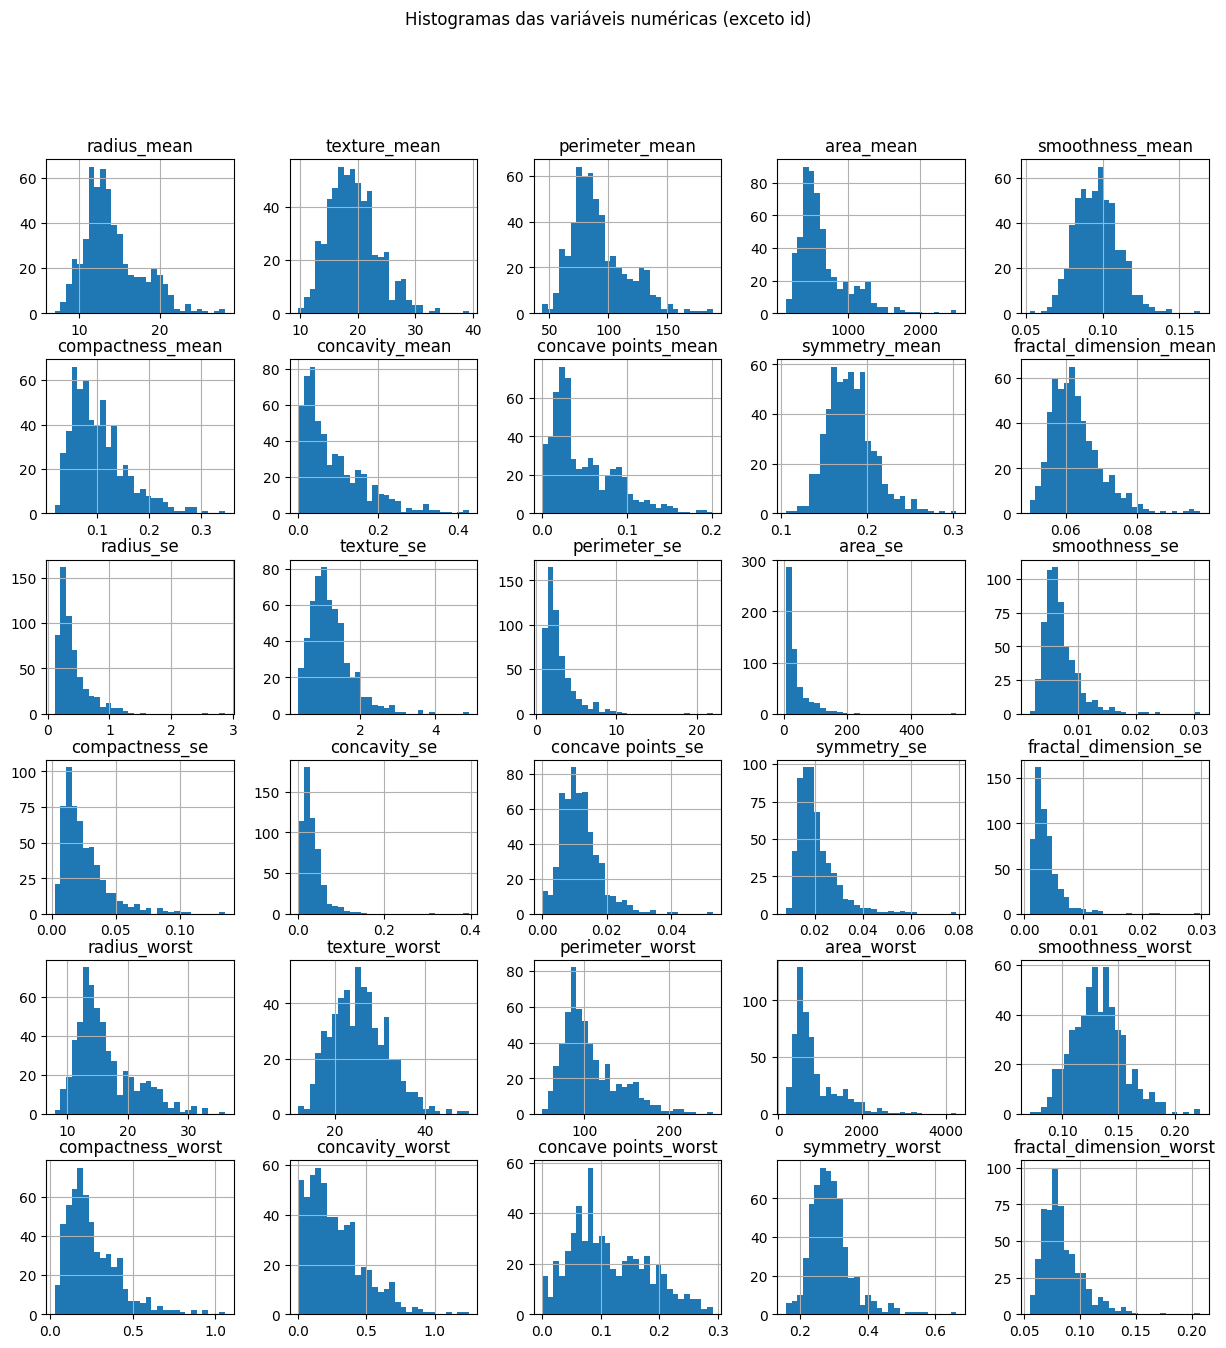

In [42]:
# Plotar histogramas
df.drop(columns=["id"]).hist(figsize=(15,15), bins=30)
plt.suptitle("Histogramas das variáveis numéricas (exceto id)")
plt.show()

Algumas variáveis estão bem distribuídas aproximando-se de uma distribuição gaussiana (normal). Porém outras variáveis puxam o histograma para a esquerda apresentando poucas ocorrências a direita, o que pode indicar a presença de outliers.
Também podemos confirmar através do histograma que existem algumas variáveis em escalas muito diferentes, por exemplo area_mean e smoothness_mean.

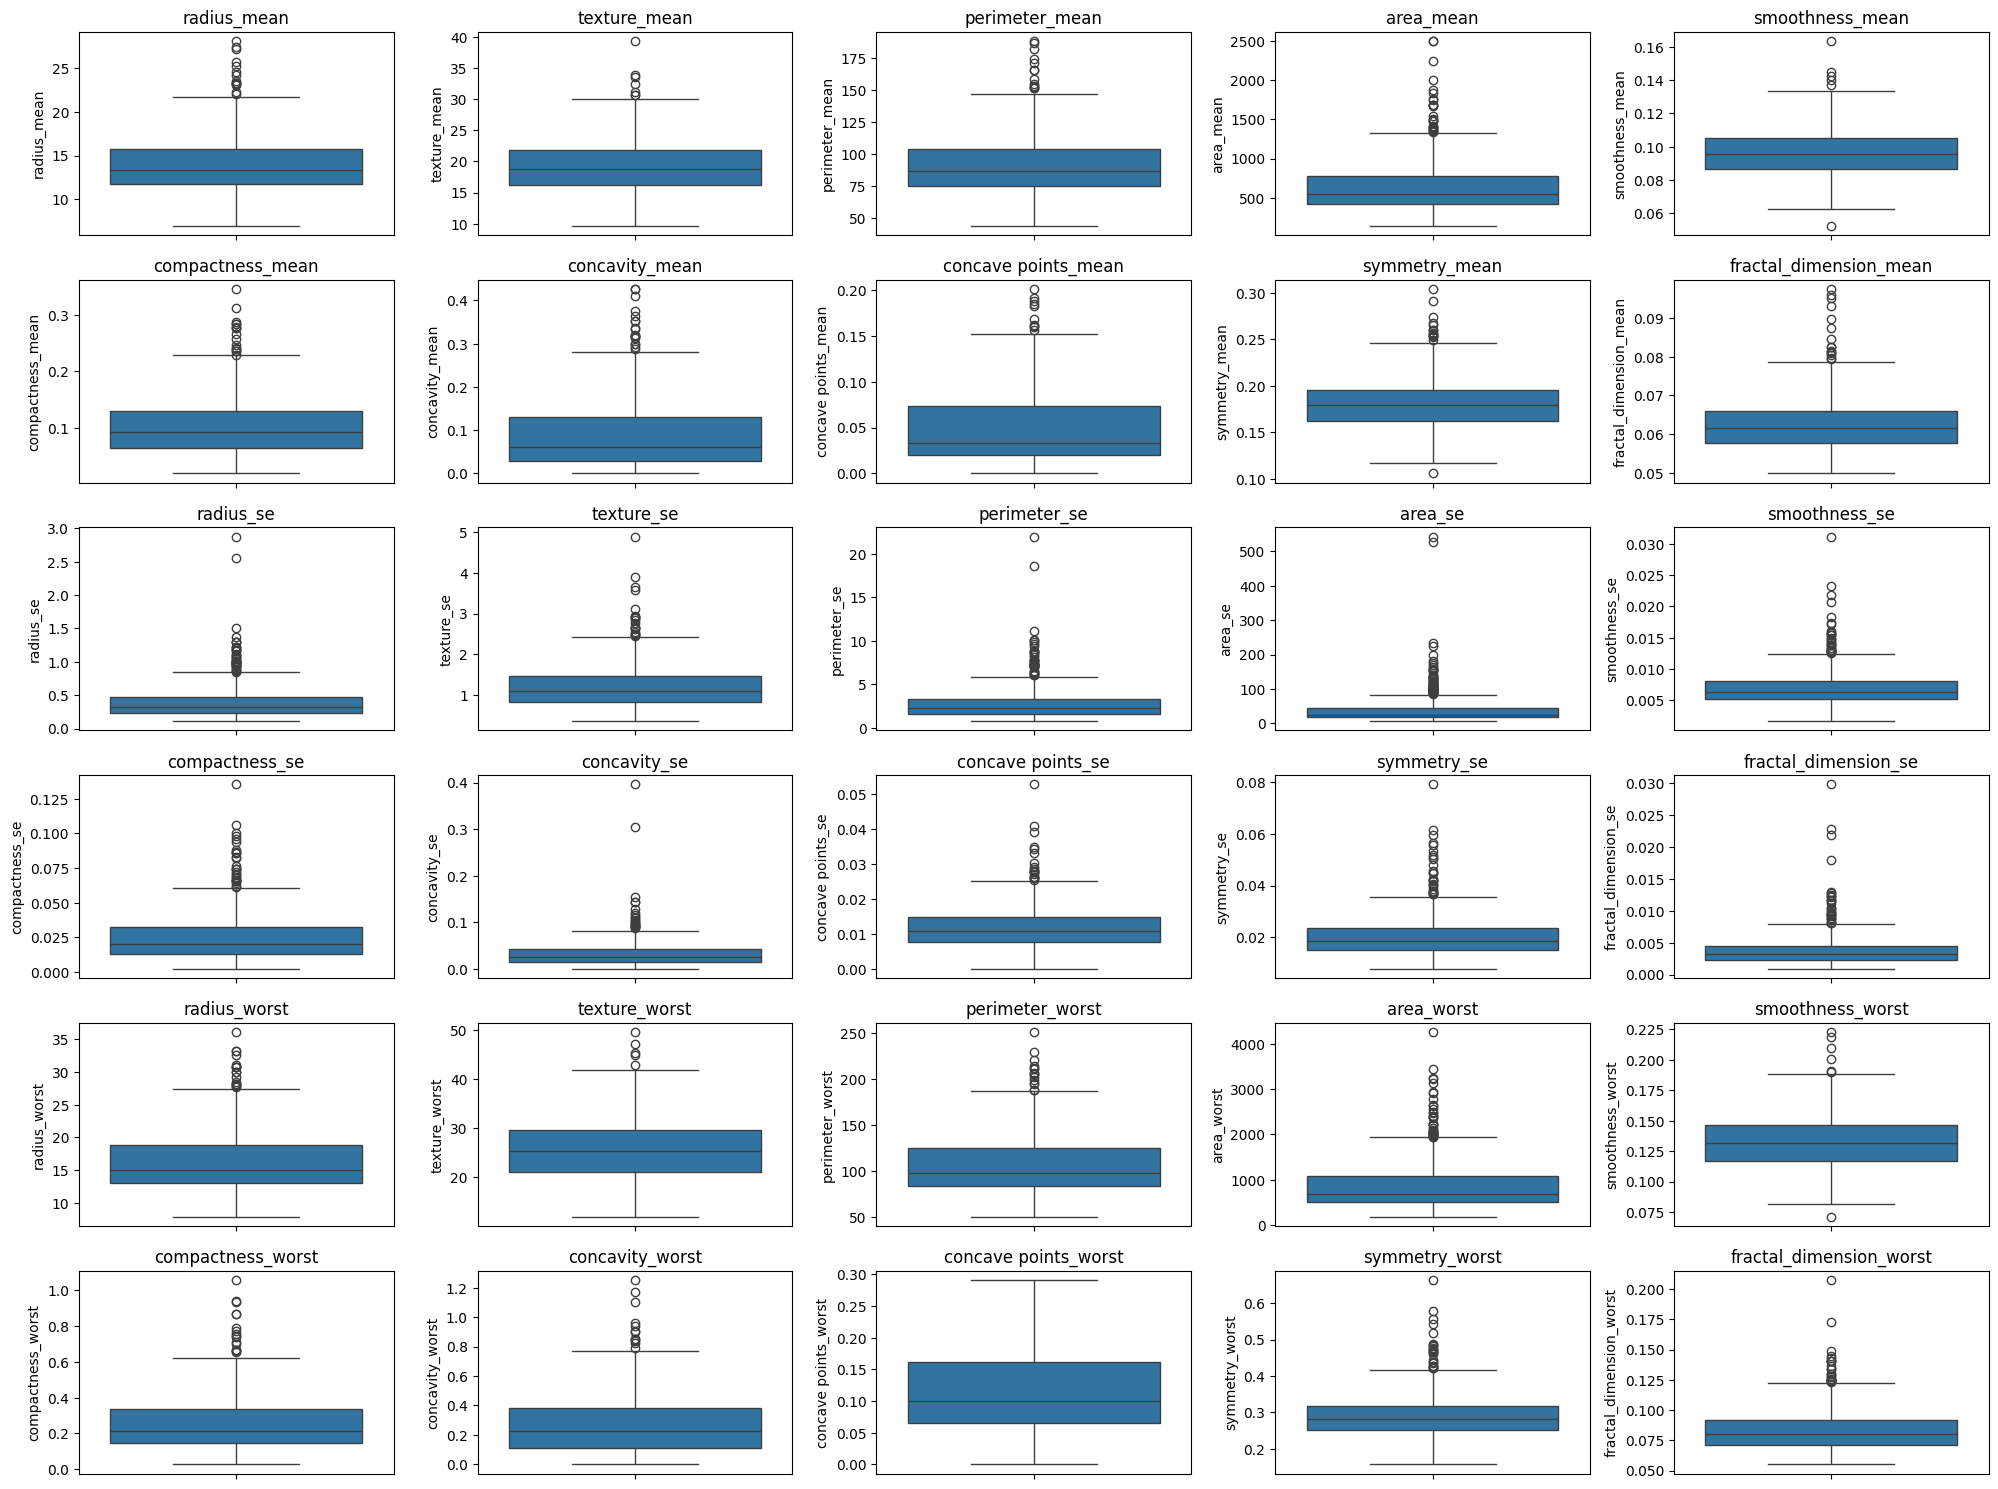

In [43]:
# Verificar a presença de outliers nas features (exceto o campo id e a colunas Unnamed que está sobrando)
plt.figure(figsize=(20, 15))
for i, col in enumerate(df.drop(columns=["id","diagnosis"]).columns, 1):
    plt.subplot(6, 5, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


Podemos verificar nos gráficos boxplot que praticamente todos os campos, exceto concave_points_worst, possuem outliers. Porém no contexto de um dataset para predição de diagnóstico baseado em características de núcleos celulares, é esperado que existam valores extremos. Se excluirmos ou alterarmos estes valores podemos comprometer sinais importantes para a predição de um tumor maligno ou benigno. Desta forma vamos manter o dataset com os outliers.

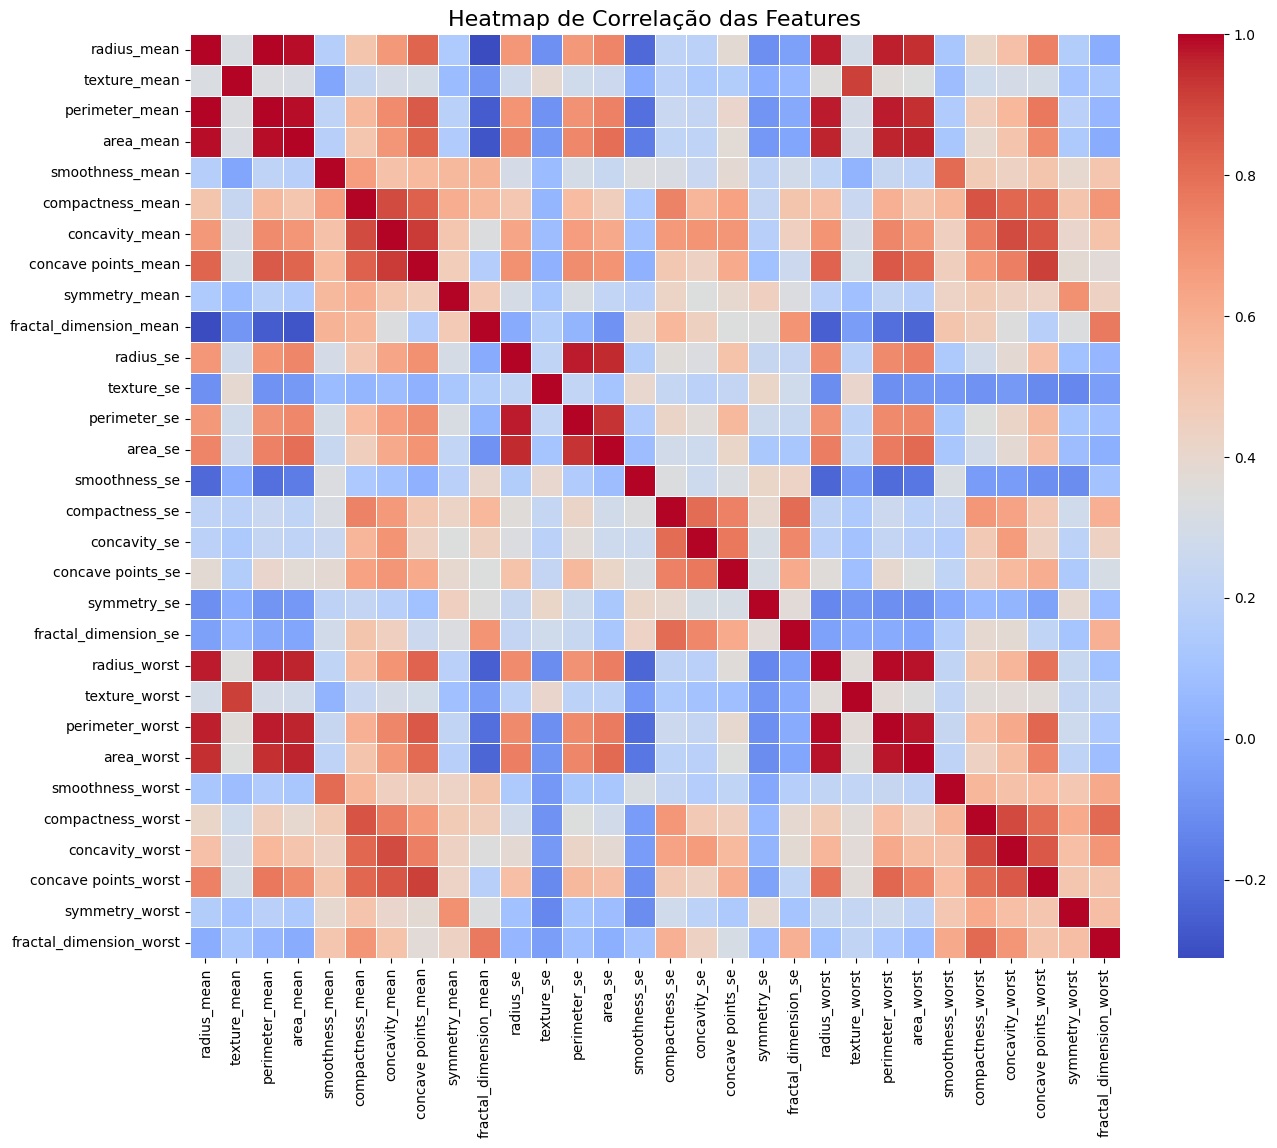

In [44]:
# Plotar heatmap de correlação
plt.figure(figsize=(15,12))
sns.heatmap(df.drop(columns=["id","diagnosis"]).corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap de Correlação das Features", fontsize=16)
plt.show()

## 4. Preparação dos dados

In [45]:
# Separando as features do target
X = df.drop(columns=["id","diagnosis"])
y = df["diagnosis"]

# Tranformando a variável target categórica em uma variável numérica
y = LabelEncoder().fit_transform(y)


### Criando pipeline para Random Forest Classifier

In [46]:
# Criar pipeline de pré-processamento
preprocessor_scaler = ColumnTransformer([
    ("num", StandardScaler(), X.columns) # deixa todas variáveis numéricas na mesma escala
])

In [47]:
# Separa base de treino e teste usando stratify para garantir que a proporção de benignos/malignos seja mantida tanto no treino quanto no teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df["diagnosis"])

### Aplicando o algoritmo Random Forest Classifier

In [48]:
random_forest_pipeline = Pipeline([
    ("preprocessorScaler", preprocessor_scaler),
    ("randomForest", RandomForestClassifier(
        n_estimators=100,      # número de árvores
        random_state=42,       # reprodutibilidade
        n_jobs=-1              # usa todos os núcleos disponíveis
    ))
])

# Treina o modelo
random_forest_pipeline.fit(X_train, y_train)

# Faz previsões
y_pred_random = random_forest_pipeline.predict(X_test)
y_prob_random = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [49]:
def plotMatrix(test, pred):
    # Criar matriz de confusão
    cm = confusion_matrix(test, pred)

    # Plotar com seaborn para melhor visualização
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()

In [50]:
# Avaliar modelo
accuracy = accuracy_score(y_test, y_pred_random)
f1 = f1_score(y_test, y_pred_random)

print(f"Acurácia: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_random))



Acurácia: 0.9737
F1-score: 0.9630

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



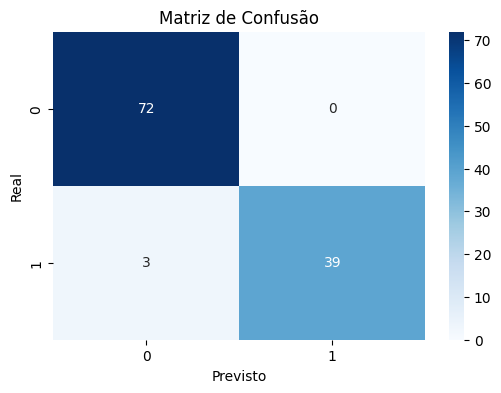

In [51]:
plotMatrix(y_test, y_pred_random)

### Aplicando o algoritmo K-NN

In [52]:
#dados → StandardScaler → KNN → previsão
knn_pipeline = Pipeline([
     ("scaler", StandardScaler()),
     ("knn", KNeighborsClassifier(n_neighbors=3))
])

In [53]:
#treinar knn
knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

In [54]:
# avaliar
accuracy = accuracy_score(y_test, y_pred_knn)

In [55]:
f1 = f1_score(y_test, y_pred_knn, average="macro")


In [56]:
print(f"Acurácia: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_knn))


Acurácia: 0.9386
F1-score: 0.9322

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



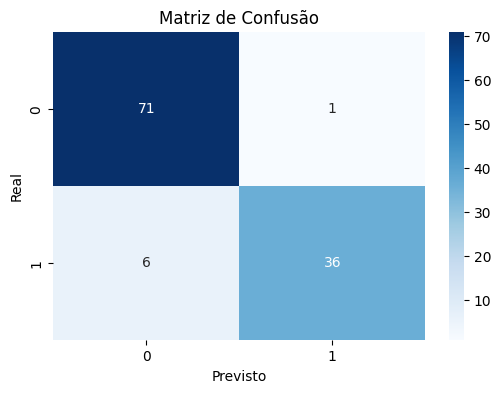

In [57]:
plotMatrix(y_test, y_pred_knn)

## 6. Avaliação

### Resultado obtidos


Os modelos foram avaliados no conjunto de teste (20% dos dados, com stratify para manter a proporção de classes). Os resultados observados nos dois modelos aplicados foram.
| Métrica | Definição | Importância no Contexto |
|---|---|---|
| **Acurácia** | Proporção de predições corretas | Visão geral útil, mas insuficiente se isolada |
| **Recall (Sensibilidade)** | TP / (TP + FN) — malignos corretamente detectados | **MÉTRICA MAIS CRÍTICA**: FN = não detectar câncer = risco de vida |
| **Precision** | TP / (TP + FP) | Importante, mas secundária — FP gera apenas exames adicionais |
| **F1-Score** | Média harmônica Precision × Recall | Equilíbrio geral, bom para comparar modelos |
| **ROC-AUC** | Área sob a curva ROC | Avalia discriminação independente do threshold |



In [60]:
def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        'Modelo': model_name,
        'Acurácia': accuracy_score(y_true, y_pred),
        'Recall (Maligno)': recall_score(y_true, y_pred),
        'Precision (Maligno)': precision_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

metrics_rf  = get_metrics(y_test, y_pred_random, y_prob_random, 'Random Forest')
metrics_knn = get_metrics(y_test, y_pred_knn,    y_prob_knn,    'KNN (k=3)')

df_metrics = pd.DataFrame([metrics_rf, metrics_knn]).set_index('Modelo')
df_metrics.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0)

,Acurácia,Recall (Maligno),Precision (Maligno),F1-Score,ROC-AUC
Modelo,,,,,
Random Forest,0.9737,0.9286,1.0000,0.9630,0.9929
KNN (k=3),0.9386,0.8571,0.9730,0.9114,0.9825


Em termos práticos, o Random Forest errou em menos de 3 casos a cada 100. O KNN errou em aproximadamente 5 a cada 100. Ambos os desempenhos são expressivos, mas o que importa mais do que o número geral é entender em que tipo de erro cada modelo falha.
- Dizer que um tumor é benigno quando na verdade é maligno: este é o erro mais grave. O paciente pode não receber tratamento a tempo, com riscos sérios à saúde.
- Dizer que um tumor é maligno quando na verdade é benigno: este erro gera preocupação desnecessária e exames adicionais (indesejável, mas não coloca a vida em risco).


Para avaliar essa questão precisamos olhar as matrizes de confusão geradas e a métrica recall. O recall para a classe Maligno é a métrica prioritária já que um Falso Negativo (FN) significa não detectar um tumor maligno o que leva a consequências potencialmente fatais. Mesmo que isso aumente levemente os alarmes falsos (FP), o custo clínico de um FP é muito menor: resulta apenas em exames adicionais.

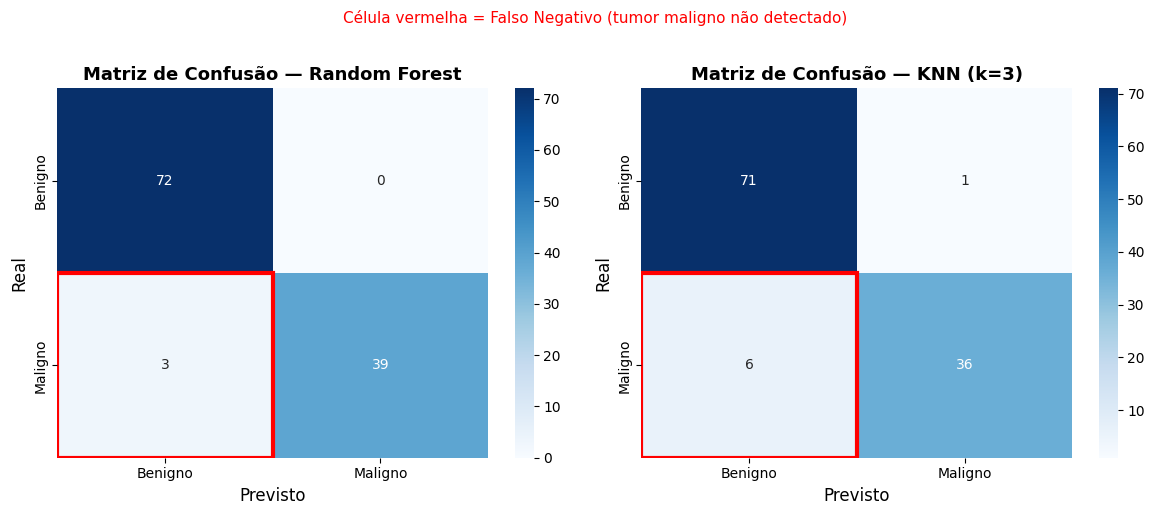

In [61]:
# ── Matrizes de Confusão ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in zip(axes,
                             ['Random Forest', 'KNN (k=3)'],
                             [y_pred_random, y_pred_knn]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'])
    ax.set_xlabel('Previsto', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)
    ax.set_title(f'Matriz de Confusão — {name}', fontsize=13, fontweight='bold')

    # Anotar FN (célula crítica: Real=Maligno, Previsto=Benigno)
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                                edgecolor='red', lw=3, label='FN (crítico)'))

plt.suptitle('Célula vermelha = Falso Negativo (tumor maligno não detectado)',
             fontsize=11, color='red', y=1.02)
plt.tight_layout()
plt.show()

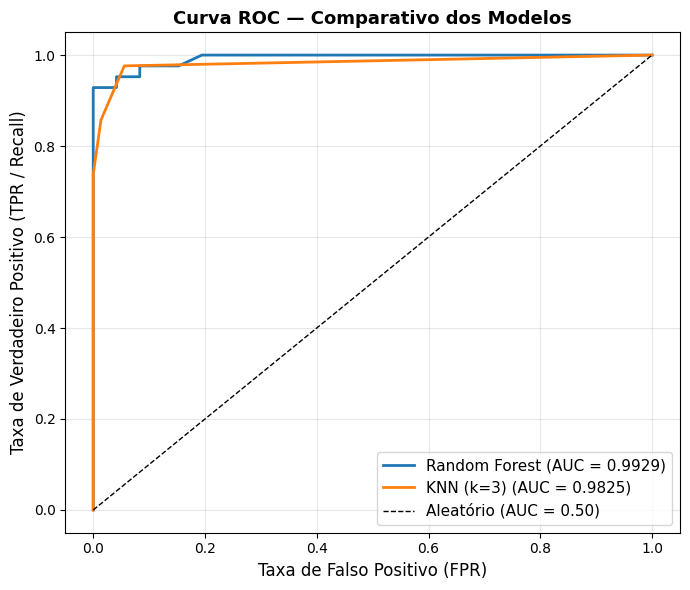

In [64]:
# ── Curva ROC ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob, color in [
    ('Random Forest', y_prob_random, '#1f77b4'),
    ('KNN (k=3)',     y_prob_knn,    '#ff7f0e')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Aleatório (AUC = 0.50)')
ax.set_xlabel('Taxa de Falso Positivo (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiro Positivo (TPR / Recall)', fontsize=12)
ax.set_title('Curva ROC — Comparativo dos Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Dessa forma comparando as matrizes de confusão e a curva ROC observamos uma pequena diferença entre os modelos. Essa diferença, embora pareça pequena, é clinicamente relevante. Em um hospital que analisa mil biópsias por mês, a diferença entre ~4% e ~6% de casos malignos não detectados representa dezenas de pacientes. Por isso o Random Forest é o modelo recomendado para este contexto.

##Interpretabilidade: Feature Importance e SHAP
### Feature Importance — Random Forest
O Random Forest fornece nativamente `feature_importances_`, que mede a redução média de impureza (Gini) atribuída a cada feature ao longo de todas as árvores.

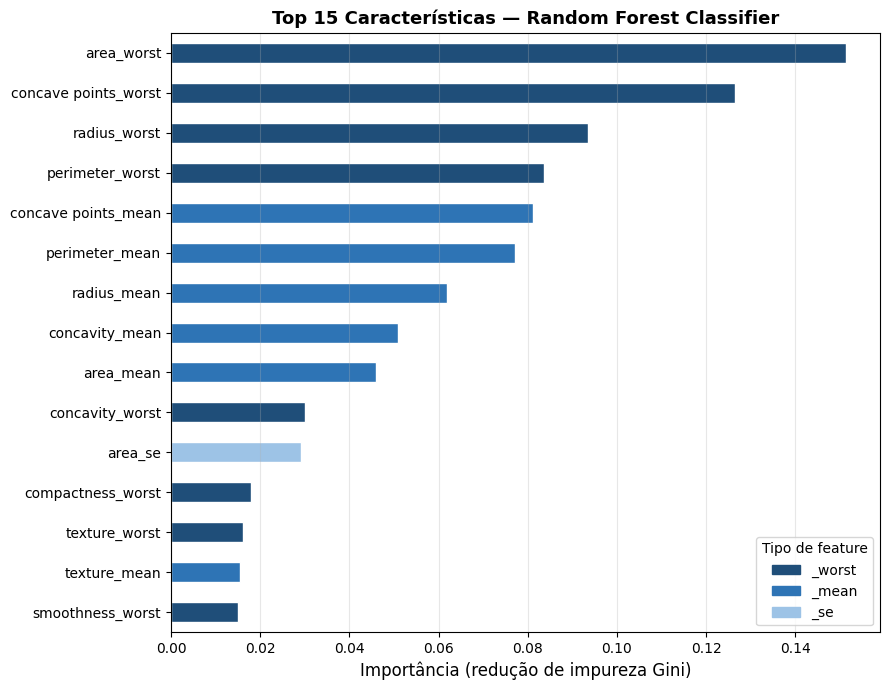


Top 10 Características por importância:
                      Importância
area_worst                 0.1514
concave points_worst       0.1265
radius_worst               0.0935
perimeter_worst            0.0836
concave points_mean        0.0811
perimeter_mean             0.0771
radius_mean                0.0620
concavity_mean             0.0508
area_mean                  0.0459
concavity_worst            0.0300


In [70]:
rf_model = random_forest_pipeline.named_steps['randomForest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

# Pegando as 15 maiores
top15 = importances_sorted.tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#1f4e79' if '_worst' in f else '#2e74b5' if '_mean' in f else '#9dc3e6'
          for f in top15.index]
top15.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_xlabel('Importância (redução de impureza Gini)', fontsize=12)
ax.set_title('Top 15 Características — Random Forest Classifier', fontsize=13, fontweight='bold')

patches = [
    mpatches.Patch(color='#1f4e79', label='_worst'),
    mpatches.Patch(color='#2e74b5', label='_mean'),
    mpatches.Patch(color='#9dc3e6', label='_se'),
]
ax.legend(handles=patches, title='Tipo de feature', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#Restringindo as top 10 características
print('\nTop 10 Características por importância:')
print(importances_sorted.tail(10).sort_values(ascending=False).to_frame('Importância').round(4))

###SHAP — SHapley Additive exPlanations
O SHAP é baseado na teoria dos jogos cooperativos (valores de Shapley) e oferece vantagens sobre a Feature Importance como direção do efeito e explicação por amostra. Usamos `TreeExplainer` por ser otimizado para modelos baseados em árvores.


Forma dos valores SHAP: (114, 30)
SHAP calculado para a classe Maligno (1)


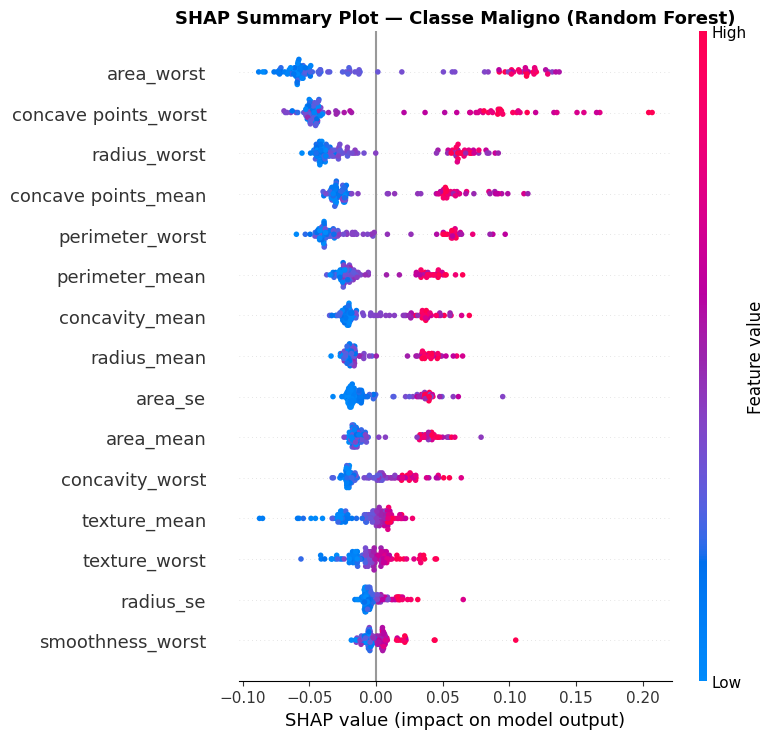

In [76]:
# Preparação do SHAP
# Extraindo dados escalados do pipeline
X_test_scaled = random_forest_pipeline.named_steps['preprocessorScaler'].transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# TreeExplainer — eficiente para Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled_df)

# shap_values[1] = valores SHAP para a classe Maligno (1)
if isinstance(shap_values, list):
    shap_maligno = shap_values[1]
else:
    shap_maligno = shap_values[:, :, 1]

print(f'Forma dos valores SHAP: {shap_maligno.shape}')
print('SHAP calculado para a classe Maligno (1)')

# Cada ponto = 1 paciente
# Posição horizontal = contribuição para predição de Maligno
# Cor = valor da feature (vermelho=alto, azul=baixo)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_maligno,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — Classe Maligno (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

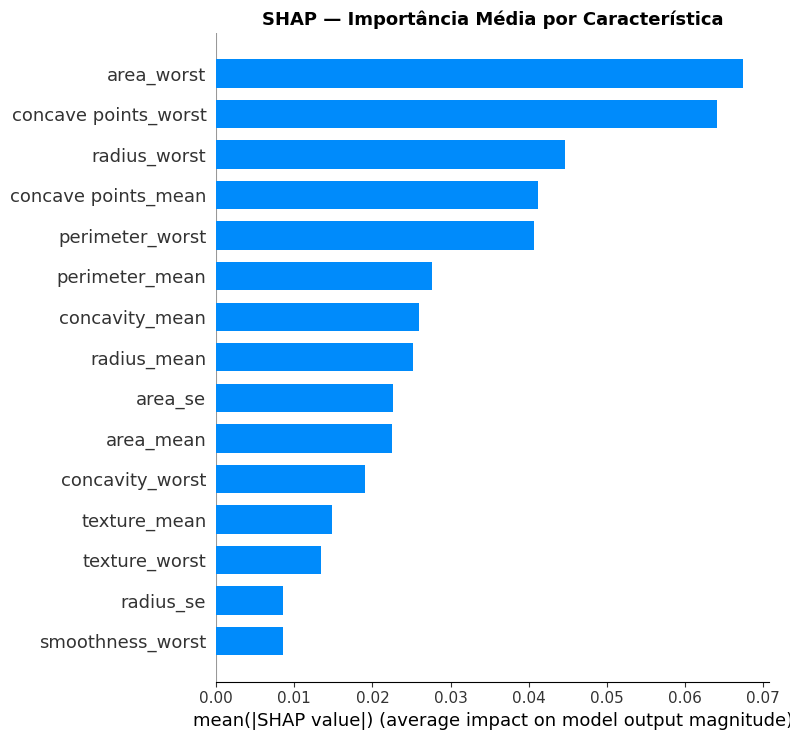

In [83]:
# SHAP Importância média global
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_maligno,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Importância Média por Característica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Amostra #1 | Real: Maligno | Previsto: Maligno

Force Plot — Características em vermelho empurram para Maligno, azul para Benigno:


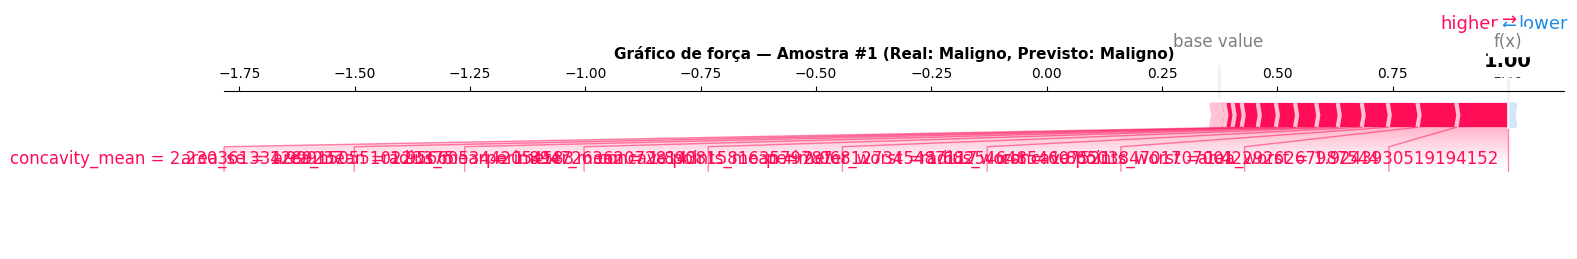

In [82]:
#SHAP Explicação Individual
# Escolhemos o primeiro caso maligno do conjunto de teste para análise

idx_maligno = np.where(y_test == 1)[0][0]  # primeiro caso maligno
pred_label = 'Maligno' if y_pred_random[idx_maligno] == 1 else 'Benigno'
real_label = 'Maligno' if y_test[idx_maligno] == 1 else 'Benigno'

print(f'Amostra #{idx_maligno} | Real: {real_label} | Previsto: {pred_label}')
print('\nForce Plot — Características em vermelho empurram para Maligno, azul para Benigno:')

shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_maligno[idx_maligno],
    X_test_scaled_df.iloc[idx_maligno],
    feature_names=X.columns.tolist(),
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title(f'Gráfico de força — Amostra #{idx_maligno} (Real: {real_label}, Previsto: {pred_label})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Feature mais importante: area_worst


<Figure size 800x500 with 0 Axes>

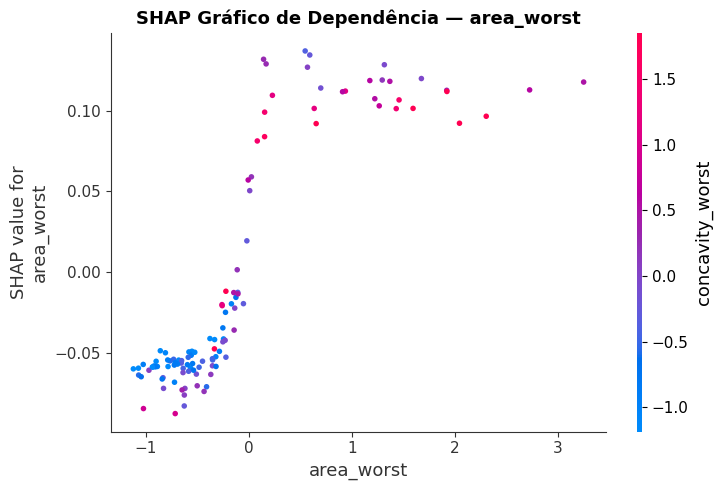

In [81]:
# SHAP de característica mais importante
# Mostra relação entre valor da feature e seu impacto SHAP
# A cor representa a interação com outra feature (escolhida automaticamente pelo SHAP)

top_feature = importances.idxmax()
print(f'Feature mais importante: {top_feature}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_maligno,
    X_test_scaled_df,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f'SHAP Gráfico de Dependência — {top_feature}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

De acordo com os dados obtidos e gráficos tanto por meio da técnica de Feature Importance e SHAP observamos que as duas são convergentes demonstrando que as características com `_worst` dominam em ambas as análises.

- Características extremas de núcleos celulares (valor máximo observado) são mais diagnósticas do que médias, pois uma única célula atípica pode sinalizar malignidade.
- `concave_points_worst`, `perimeter_worst` e `radius_worst` são consistentemente as mais relevantes.

O SHAP adiciona direção: pontos vermelhos (valores altos) à direita no Summary Plot confirmam que valores altos dessas features aumentam a probabilidade de classificação como Maligno.

Com isso, temos candidatas à redução de dimensionalidade por apresentarem valores baixos (ex: `texture_se`, `fractal_dimension_mean`). Essas características poderiam ser removidas sem impacto significativo no desempenho, simplificando o modelo.

###Uso na prática
Os resultados mostram que o modelo tem desempenho suficiente para ser útil em um contexto clínico real, porém não como substituto do diagnóstico médico e sim complementar/auxiliar. O modelo funciona como um assistente experiente, que analisou várias biópsias e aprendeu a reconhecer padrões, sendo assim ele pode sinalizar riscos, priorizar casos urgentes e oferecer uma segunda opinião, mas a decisão final sempre cabe ao médico.

Como potencial de uso desse modelo temos

| Aplicação | Descrição |
|---|---|
| **Triagem** | Sinalizar automaticamente casos com maior probabilidade de malignidade, priorizando-os na fila de análise médica |
| **Opinião computacional** | Em casos limítrofes, fornecer perspectiva adicional baseada em padrões estatísticos |
| **Redução de variabilidade** | Diagnósticos por análise visual sofrem variabilidade inter-observador; o modelo padroniza |

Apesar dos resultados interessantes, ainda há etapas importantes que precisariam ser cumpridas antes de qualquer implantação:
- Validação com novos pacientes: o modelo foi avaliado com dados do mesmo estudo que gerou o conjunto de treinamento. Antes do uso real, seria necessário testá-lo com biópsias de outros hospitais, equipamentos e populações para verificar se o desempenho se mantém.
- Incorporação de mais informações clínicas: atualmente, o modelo considera apenas as características celulares. Integrar informações como idade da paciente, histórico familiar e resultado de mamografia tornaria as previsões mais completas e confiáveis.
- Aprovação regulatória: no Brasil, qualquer software com finalidade diagnóstica precisa de aprovação da ANVISA antes de ser utilizado em ambiente hospitalar.

O modelo vem como mais uma ferramenta de apoio para auxiliar os médicos no seu dia dia apoiado por novas tecnologias como o uso de inteligência artificial.
